# 01 - Exploratory Data Analysis (EDA)
## Proyek: RoadDamage_AI (Deteksi Kerusakan Jalan dengan YOLOv8n)

### Tujuan Notebook
Notebook ini bertujuan untuk melakukan **eksplorasi dan pemahaman mendalam terhadap dataset** sebelum proses pemodelan, mencakup:
1. Mengetahui jumlah total gambar dan file anotasi.
2. Memeriksa resolusi dan dimensi gambar.
3. Menganalisis jumlah objek per kelas dan mendeteksi **Class Imbalance**.
4. Menganalisis distribusi ukuran bounding box (lebar & tinggi).
5. Memvisualisasikan contoh gambar beserta bounding box asli.


In [1]:
%matplotlib inline
import os
import glob
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# Set style visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = os.path.abspath("../data")
IMAGES_DIR = os.path.join(DATA_DIR, "images")
LABELS_YOLO_DIR = os.path.join(DATA_DIR, "labels-YOLO")

print(f"Data Directory: {DATA_DIR}")
print(f"Images Directory: {IMAGES_DIR}")
print(f"YOLO Labels Directory: {LABELS_YOLO_DIR}")


Data Directory: z:\Projects\RoadDamage_AI\data
Images Directory: z:\Projects\RoadDamage_AI\data\images
YOLO Labels Directory: z:\Projects\RoadDamage_AI\data\labels-YOLO


---
### 1. Memeriksa Jumlah Gambar dan File Anotasi
Mari kita periksa apakah semua gambar memiliki label YOLO yang berpasangan secara 1:1.


In [2]:
image_files = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.jpg")))
label_files = sorted(glob.glob(os.path.join(LABELS_YOLO_DIR, "*.txt")))

print(f"Total Gambar: {len(image_files)}")
print(f"Total File Label YOLO: {len(label_files)}")

img_stems = {os.path.splitext(os.path.basename(f))[0] for f in image_files}
lbl_stems = {os.path.splitext(os.path.basename(f))[0] for f in label_files}

print(f"Gambar tanpa label: {len(img_stems - lbl_stems)}")
print(f"Label tanpa gambar: {len(lbl_stems - img_stems)}")


Total Gambar: 2009
Total File Label YOLO: 2009
Gambar tanpa label: 0
Label tanpa gambar: 0


---
### 2. Memeriksa Resolusi Gambar
Mari kita periksa ukuran pixel dari gambar dataset.


In [3]:
resolutions = Counter()
for img_path in image_files[:100]:
    with Image.open(img_path) as img:
        resolutions[img.size] += 1

for res, count in resolutions.items():
    print(f"Resolusi (Width x Height): {res[0]} x {res[1]} px -> {count} sampel")


Resolusi (Width x Height): 640 x 360 px -> 100 sampel


---
### 3. Ekstraksi dan Analisis Distribusi Kelas
Dataset ini memiliki 3 kelas kerusakan jalan:
- **Class 0:** Pothole (Lubang Jalan)
- **Class 1:** Crack (Retakan Permukaan Jalan)
- **Class 2:** Manhole (Penutup Saluran / Got)


In [4]:
CLASS_NAMES = {0: "Pothole", 1: "Crack", 2: "Manhole"}
CLASS_COLORS = {"Pothole": "#f59e0b", "Crack": "#f43f5e", "Manhole": "#06b6d4"}

box_data = []

for lbl_path in label_files:
    img_name = os.path.splitext(os.path.basename(lbl_path))[0] + ".jpg"
    with open(lbl_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                xc, yc, w, h = map(float, parts[1:])
                box_data.append({
                    "image": img_name,
                    "class_id": cls_id,
                    "class_name": CLASS_NAMES.get(cls_id, f"Unknown_{cls_id}"),
                    "x_center": xc,
                    "y_center": yc,
                    "width": w,
                    "height": h,
                    "area": w * h
                })

df_boxes = pd.DataFrame(box_data)
print(f"Total Bounding Box: {len(df_boxes)}")
df_boxes.head()


Total Bounding Box: 4737


,image,class_id,class_name,x_center,y_center,width,height,area
0,20250216_164325.jpg,2,Manhole,0.466407,0.552778,0.298437,0.144444,0.043107
1,20250216_164325.jpg,0,Pothole,0.604688,0.556944,0.043751,0.113889,0.004983
2,20250216_164325.jpg,0,Pothole,0.285156,0.544444,0.051562,0.055555,0.002865
3,20250216_164325.jpg,0,Pothole,0.387500,0.498611,0.053124,0.047222,0.002509
4,20250216_164325.jpg,1,Crack,0.421875,0.672222,0.050000,0.088889,0.004444


---
### 4. Visualisasi Distribusi Kelas & Analisis Imbalance
Mari kita visualisasikan perbandingan jumlah objek per kelas.


=== RINGKASAN DISTRIBUSI KELAS ===
            Jumlah Objek  Persentase (%)
class_name                              
Crack               2519           53.18
Pothole             1261           26.62
Manhole              957           20.20


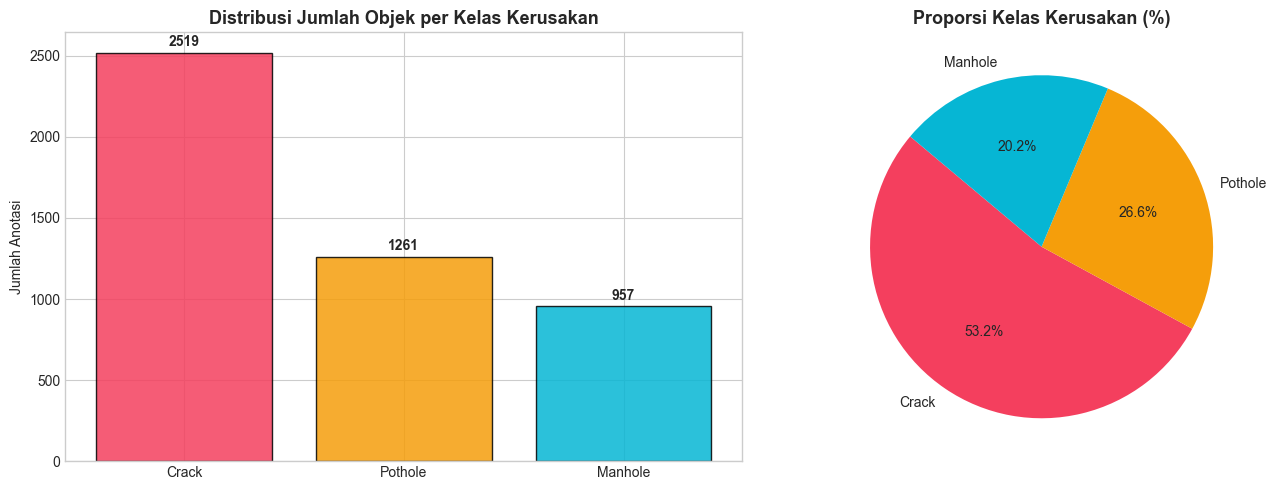

In [5]:
class_counts = df_boxes['class_name'].value_counts()
class_pct = (class_counts / len(df_boxes) * 100).round(2)

df_summary = pd.DataFrame({
    'Jumlah Objek': class_counts,
    'Persentase (%)': class_pct
})
print("=== RINGKASAN DISTRIBUSI KELAS ===")
print(df_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [CLASS_COLORS[c] for c in class_counts.index]
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Jumlah Objek per Kelas Kerusakan', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Anotasi')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 40, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Proporsi Kelas Kerusakan (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


#### Temuan Analisis Imbalance:
1. **Crack (53.2%)** mendominasi dataset dengan lebih dari separuh total objek.
2. **Pothole (26.6%)** berada pada proporsi sedang.
3. **Manhole (20.2%)** merupakan kelas minoritas (~957 objek).
4. **Dampak pada ML:** Model YOLOv8 mungkin lebih mudah mendeteksi retakan (*Crack*), namun metrik untuk *Manhole* dan *Pothole* perlu dipantau secara khusus agar tidak bias terhadap kelas mayoritas.


---
### 5. Analisis Dimensi Bounding Box (Lebar, Tinggi, dan Area)


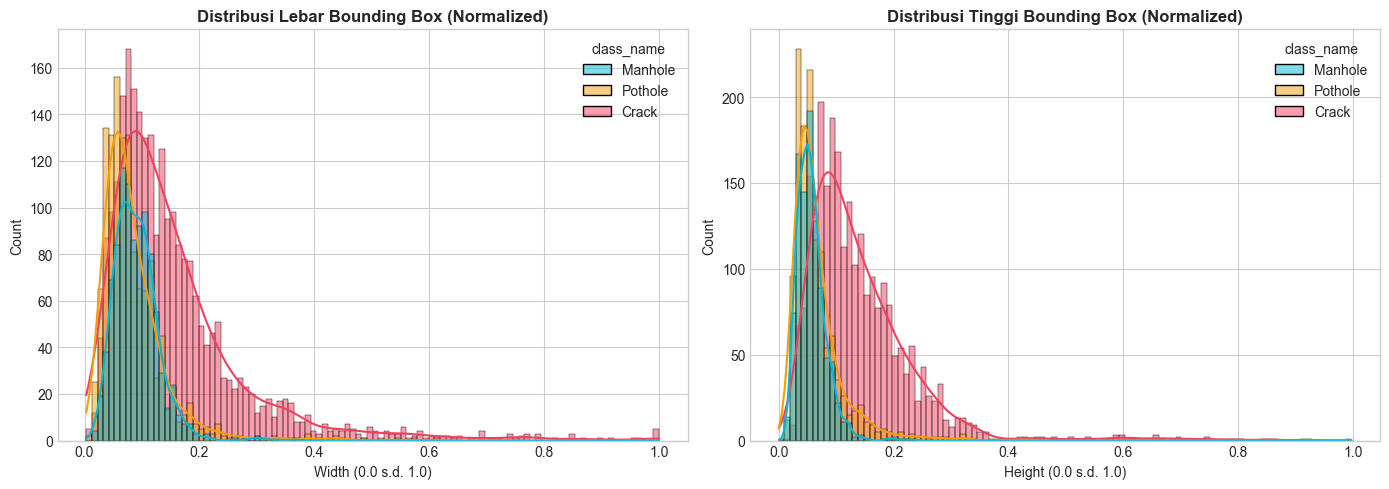

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_boxes, x='width', hue='class_name', palette=CLASS_COLORS, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Lebar Bounding Box (Normalized)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (0.0 s.d. 1.0)')

sns.histplot(data=df_boxes, x='height', hue='class_name', palette=CLASS_COLORS, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Tinggi Bounding Box (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Height (0.0 s.d. 1.0)')

plt.tight_layout()
plt.show()


---
### 6. Visualisasi Sampel Gambar dengan Bounding Box Asli


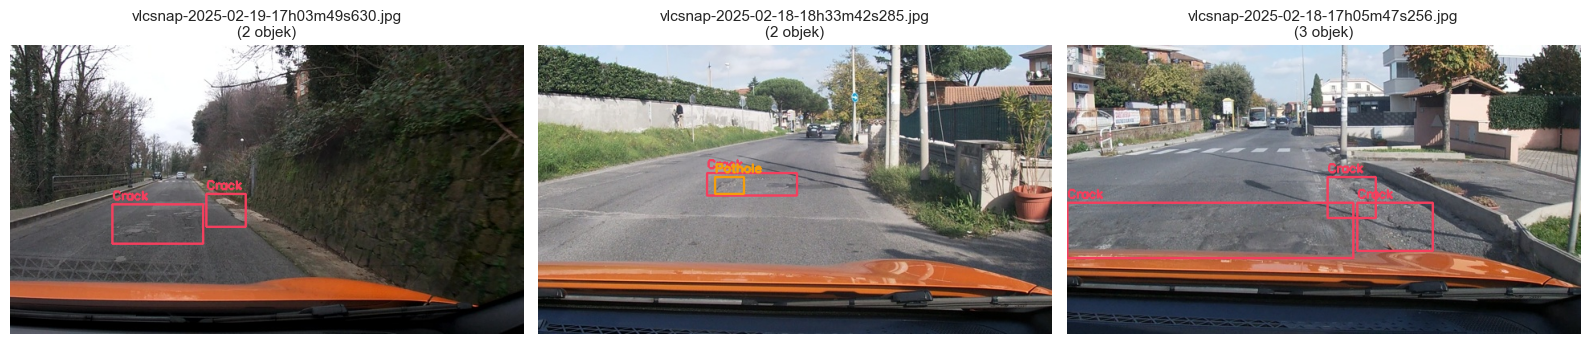

In [7]:
def plot_sample_images(df, images_dir, num_samples=3):
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 5))
    sample_imgs = df['image'].drop_duplicates().sample(num_samples, random_state=42).tolist()
    
    color_map_bgr = {
        0: (245, 158, 11),
        1: (244, 63, 94),
        2: (6, 182, 212)
    }

    for idx, img_name in enumerate(sample_imgs):
        img_path = os.path.join(images_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        boxes_for_img = df[df['image'] == img_name]
        
        for _, row in boxes_for_img.iterrows():
            cid = int(row['class_id'])
            xc, yc, bw, bh = row['x_center'], row['y_center'], row['width'], row['height']
            
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)
            
            color = color_map_bgr.get(cid, (255, 255, 255))
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, row['class_name'], (x1, max(y1 - 6, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            
        axes[idx].imshow(img)
        axes[idx].set_title(f"{img_name}\n({len(boxes_for_img)} objek)", fontsize=11)
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_sample_images(df_boxes, IMAGES_DIR, num_samples=3)


---
### 7. Kesimpulan EDA
1. **Integritas Dataset:** 2,009 gambar dan 2,009 label YOLO cocok 1:1 tanpa data yang hilang.
2. **Karakteristik Visual:** Gambar beresolusi 640x360 pixel, diambil dari sudut pandang kendaraan (*dashcam/vehicle mount*).
3. **Distribusi Kelas:** Terjadi *imbalance* dengan proporsi Crack (53.2%), Pothole (26.6%), dan Manhole (20.2%).
4. **Langkah Berikutnya:** Melakukan data preprocessing dan dataset splitting (Train 70%, Val 20%, Test 10%) di notebook `02_Data_Preprocessing.ipynb`.
